# Marketing Campaign Offer Optimization — Ingosstrakh case

**Task:** for each client, choose at most one (or, where the constraint file allows, a few) product+channel
offer that maximizes total expected value, subject to a heterogeneous, dynamically-shaped set of business
constraints (budget caps, per-channel/per-product/per-segment/per-client limits).

$$EV = Margin \times Premium \times Response - Cost, \qquad \sum_n EV_n \rightarrow MAX$$

Three graduated datasets are provided (`low`, `med`, `hard`), each with a genuinely different file dialect
(delimiter, decimal separator, wide-vs-long shape) and a genuinely different EV formula variant — see the
readme. This notebook runs **one uniform pipeline** (`offer_opt`) across all three, built around a
Lagrangian relaxation solver:

- each client's offer choice is a small, independent local subproblem (enforced exactly every iteration)
- the shared/global constraints (budget, per-channel/product/segment totals) are dualized into Lagrange
  multipliers, updated by subgradient ascent
- the whole per-client selection step is vectorized PyTorch tensor ops (`scatter_reduce_`/`scatter_add_`),
  so it runs unmodified on CPU, CUDA, or Apple's MPS backend


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()))

import pandas as pd
import matplotlib.pyplot as plt
import torch

from offer_opt import constraints as C
from offer_opt import features as F
from offer_opt import metrics as M
from offer_opt import pipeline as P
from offer_opt import verify as V
from offer_opt.device import get_device
from offer_opt.io import dialects as D
from offer_opt.io import raw_constraints as RC

pd.set_option("display.max_rows", 20)
CASES = ["low", "med", "hard"]


Matplotlib is building the font cache; this may take a moment.


## 1. The constraint tables are heterogeneous strings, not fixed code paths

Three different file dialects (tab vs comma vs semicolon delimiters, `.` vs `,` decimals, BOM, quoting),
three different constraint-type vocabularies. `med` and `hard` share the same tabular schema; `low`'s is a
flat `KEY=VALUE` format with no explicit scoping columns at all.


In [2]:
print("=== constraint_low.txt (raw) ===")
print(pathlib.Path(D.CASE_FILES["low"]["constraints"]).read_text(encoding="utf-8-sig"))

print("=== constraint_med.csv (first 10 rows) ===")
display(D.read_constraints_table("med").head(10))

print("=== constraint_hard.csv (first 10 rows) ===")
display(D.read_constraints_table("hard").head(10))


=== constraint_low.txt (raw) ===
CNT_OSG_SMS=10000
CNT_OSG_EMAIL=7000
CNT_KSK_SMS=4000
CNT_KSK_EMAIL=2000
=== constraint_med.csv (first 10 rows) ===


,Constraints,Channel,Product,min,max
0,cost_of_communication,EMAIL,NaN,0.02,NaN
1,cost_of_communication,SMS,NaN,5.20,NaN
2,cost_of_communication,OCRM,NaN,36.00,NaN
3,total_cost,NaN,NaN,0.00,63000.0
4,offers_per_channel_per_client,EMAIL,NaN,0.00,3.0
5,offers_per_channel_per_client,SMS,NaN,0.00,2.0
6,offers_per_channel_per_client,OCRM,NaN,0.00,1.0
7,offers_per_product_per_client,NaN,KSK,0.00,1.0
8,offers_per_product_per_client,NaN,KSK_OSG,0.00,1.0
9,offers_per_product_per_client,NaN,IFL,0.00,1.0


=== constraint_hard.csv (first 10 rows) ===


,CONSTRAINTS,CHANNEL,PRODUCT,MIN,MAX
0,cost_of_communication,EMAIL,NaN,0.02,NaN
1,cost_of_communication,SMS,NaN,8.70,NaN
2,cost_of_communication,INGOGATEAGENT,NaN,0.00,NaN
3,cost_of_communication,OCRM,NaN,37.00,NaN
4,cost_of_communication,WEB,NaN,0.00,NaN
5,cost_of_communication,MOBILE,NaN,0.00,NaN
6,total_cost,NaN,NaN,0.00,500000.000
7,margin_per_product,NaN,OVERTIME,0.00,0.165
8,margin_per_product,NaN,OSAGO,0.00,0.231
9,margin_per_product,NaN,INGOLAB,0.00,0.120


## 2. Constraint parser

`offer_opt.constraints.resolve_one` maps every raw constraint-type string onto one generic schema:
`(scope, measure, min, max, per_client)`. Two genuinely irregular vendor rows get an explicit, documented
override (`cost_of_communication` / `margin_per_product` turn out to be **parameters** that feed the EV
formula, not constraints at all — verified arithmetically against the hard reference row); every other
type — `total_cost`, `cost_per_channel`, `offers_per_product`, `offers_per_channel_per_client`, … — is
resolved purely by naming convention, so a brand-new constraint type of the same shape needs **zero code
changes**. The solver and verifier downstream only ever see the resolved schema, never the raw type name.


In [3]:
rows = RC.from_table(D.read_constraints_table("med"))
cs = C.resolve_all(rows)

print(f"{len(cs.constraints)} constraints, {len(cs.parameters)} parameters resolved from constraint_med.csv\n")

display(pd.DataFrame([
    dict(id=c.id, scope=c.scope, measure=c.measure, min=c.min, max=c.max, per_client=c.per_client)
    for c in cs.constraints
]))

print("\nRows routed to `parameters` (feed the EV formula, never reach the solver/verifier as bounds):")
display(pd.DataFrame([dict(kind=p.kind, scope=p.scope, value=p.value) for p in cs.parameters]))


40 constraints, 3 parameters resolved from constraint_med.csv



,id,scope,measure,min,max,per_client
0,total_cost{},{},cost,0.0,63000.0,False
1,offers_per_channel_per_client{'channel': 'EMAIL'},{'channel': 'EMAIL'},count,0.0,3.0,True
2,offers_per_channel_per_client{'channel': 'SMS'},{'channel': 'SMS'},count,0.0,2.0,True
3,offers_per_channel_per_client{'channel': 'OCRM'},{'channel': 'OCRM'},count,0.0,1.0,True
4,offers_per_product_per_client{'product': 'KSK'},{'product': 'KSK'},count,0.0,1.0,True
...,...,...,...,...,...,...
35,"offers_per_segment{'channel': 'SMS', 'segment'...","{'channel': 'SMS', 'segment': 'IFL_AnA'}",count,20.0,NaN,False
36,"offers_per_segment{'channel': 'SMS', 'segment'...","{'channel': 'SMS', 'segment': 'IFL_DnA'}",count,NaN,NaN,False
37,"offers_per_segment{'channel': 'SMS', 'segment'...","{'channel': 'SMS', 'segment': 'KSK_OSG_AA'}",count,NaN,NaN,False
38,"offers_per_segment{'channel': 'SMS', 'segment'...","{'channel': 'SMS', 'segment': 'KSK_OSG_AnA'}",count,150.0,NaN,False



Rows routed to `parameters` (feed the EV formula, never reach the solver/verifier as bounds):


,kind,scope,value
0,cost,{'channel': 'EMAIL'},0.02
1,cost,{'channel': 'SMS'},5.20
2,cost,{'channel': 'OCRM'},36.00


## 3. Generic verifier — works standalone, on *any* solution

`offer_opt.verify.verify(offer_table, constraint_set, selection)` takes only the resolved constraint set
and a 0/1 selection vector — no branching on constraint type name or which case produced the data. As a
sanity check on the parser (independent of whether our solver even exists yet), we reconstruct the
vendor's own reference solution for the `hard` case and run it through the same verifier.


In [4]:
ref_report = M.verify_reference("hard")
print(ref_report)


PASS -- total_ev=1,378,748,080.05, n_selected=834208


## 4. Solver — one pipeline, three cases

Same `solve(offer_table, constraint_set, device)` call for `low`, `med`, and `hard` — no per-case branches
beyond the I/O dialect layer. Each client's local constraints (per-product / per-channel / low's implied
"pick one" pivot cap) are enforced exactly every iteration; global constraints are dualized and relaxed via
subgradient ascent; a deterministic repair pass guarantees the final answer is strictly feasible.


In [5]:
device = get_device(prefer_gpu=True)
print("device:", device)

SOLVE_KWARGS = dict(low=dict(), med=dict(), hard=dict(max_iters=400, repair_every=20))

results = {}
for case in CASES:
    import time
    t0 = time.perf_counter()
    results[case] = P.run_case(case, device, **SOLVE_KWARGS[case])
    dt = time.perf_counter() - t0
    r = results[case]
    print(f"{case:>5}: {dt:6.1f}s  iters={r.solve_result.iterations:<5} "
          f"verifier={'PASS' if r.verification.ok else 'FAIL':<4}  "
          f"our_ev={r.solve_result.total_ev:>15,.0f}  ref_ev={r.reference_ev:>15,.0f}  "
          f"({100*(r.solve_result.total_ev/r.reference_ev-1):+.2f}%)")


device: mps


  low:    5.2s  iters=1200  verifier=PASS  our_ev=      3,760,723  ref_ev=      3,760,755  (-0.00%)


  med:   24.6s  iters=1200  verifier=PASS  our_ev=        190,067  ref_ev=        190,038  (+0.02%)


 hard:  140.8s  iters=400   verifier=PASS  our_ev=  1,308,276,377  ref_ev=  1,378,748,080  (-5.11%)


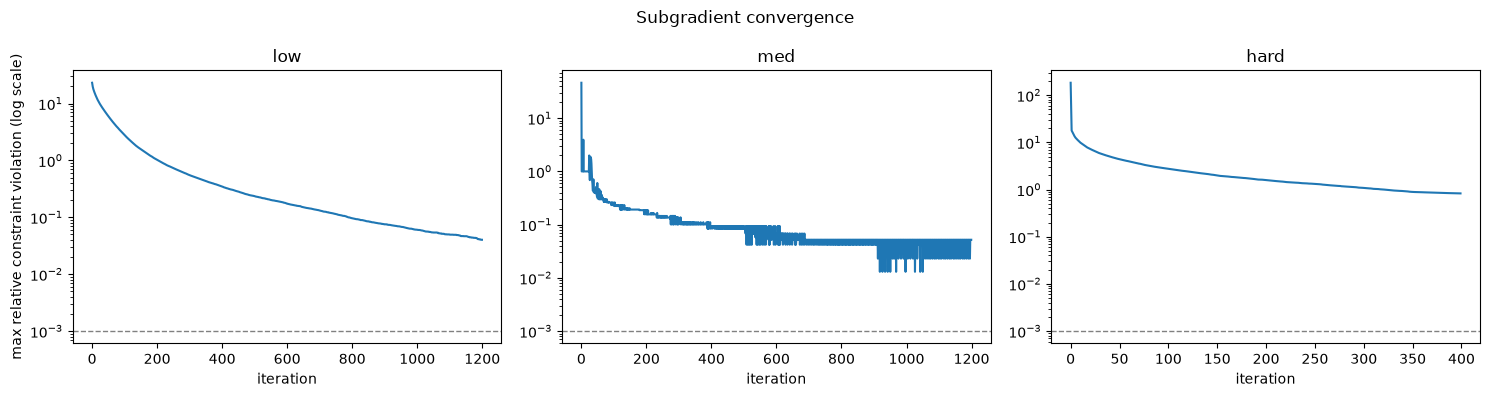

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, case in zip(axes, CASES):
    hist = results[case].solve_result.history
    ax.plot([h["iter"] for h in hist], [h["max_rel_violation"] for h in hist])
    ax.axhline(1e-3, color="grey", linestyle="--", linewidth=1)
    ax.set_title(case)
    ax.set_xlabel("iteration")
    ax.set_yscale("log")
axes[0].set_ylabel("max relative constraint violation (log scale)")
fig.suptitle("Subgradient convergence")
fig.tight_layout()
plt.show()


## 5. Summary

In [7]:
summary = pd.DataFrame([
    dict(
        case=case,
        n_clients=int(r.offer_table["client_idx"].max()) + 1,
        n_candidates=len(r.offer_table),
        n_constraints=len(r.constraint_set.constraints),
        n_parameters=len(r.constraint_set.parameters),
        iterations=r.solve_result.iterations,
        our_ev=r.solve_result.total_ev,
        reference_ev=r.reference_ev,
        ev_vs_reference=f"{100*(r.solve_result.total_ev/r.reference_ev-1):+.2f}%",
        verifier=("PASS" if r.verification.ok else "FAIL"),
    )
    for case, r in results.items()
])
display(summary)


,case,n_clients,n_candidates,n_constraints,n_parameters,iterations,our_ev,reference_ev,ev_vs_reference,verifier
0,low,100000,400000,5,0,1200,3.760723e+06,3.760755e+06,-0.00%,PASS
1,med,49966,154659,40,3,1200,1.900668e+05,1.900382e+05,+0.02%,PASS
2,hard,278346,5000000,88,9,400,1.308276e+09,1.378748e+09,-5.11%,PASS


## 6. CPU vs GPU benchmark

Median of runs per device. This section uses a **fixed, lighter iteration budget** (same for every
device) purely to compare per-iteration throughput fairly and quickly -- solution *quality* was already
established in section 4-5 above with the full iteration budget; this section is about speed, per the
rubric's fixed-hardware comparison protocol.


In [8]:
BENCH_KWARGS = dict(max_iters=50, repair_every=50, plateau_patience=10000)

bench_rows = []
devices = [torch.device("cpu")]
if torch.cuda.is_available():
    devices.append(torch.device("cuda"))
elif torch.backends.mps.is_available():
    devices.append(torch.device("mps"))

for case in CASES:
    n_reps = 5 if case != "hard" else 3
    for dev in devices:
        b = M.benchmark(case, dev, n_reps=n_reps, **BENCH_KWARGS)
        bench_rows.append(dict(case=case, device=str(dev), median_time_s=round(b["median_time"], 2),
                                iterations=b["iterations"], verifier_ok=b["verifier_ok"]))

bench_df = pd.DataFrame(bench_rows)
display(bench_df)

if len(devices) > 1:
    pivot = bench_df.pivot(index="case", columns="device", values="median_time_s")
    speedup = pivot["cpu"] / pivot[str(devices[1])]
    print("\nspeedup (cpu_time / gpu_time):")
    display(speedup)


,case,device,median_time_s,iterations,verifier_ok
0,low,cpu,0.73,50,True
1,low,mps,0.33,50,True
2,med,cpu,0.63,50,True
3,med,mps,1.16,50,True
4,hard,cpu,32.61,50,True
5,hard,mps,19.19,50,True



speedup (cpu_time / gpu_time):


case
hard    1.699323
low     2.212121
med     0.543103
dtype: float64

## 7. Design decisions worth restating

**How many offers can one client get?** The written spec (and `low`'s own reference, a single categorical
`Offer` column) says *pick the single best product+channel*. But `med` and `hard`'s own reference solutions
give most selected clients 2–3 *simultaneous* offers (one per product), because their constraint files
declare `offers_per_product_per_client ≤ 1` — a cap per product, not per client total. We derive the
per-client cap purely from what each case's own constraint file declares, with one documented exception:
`low`'s source table is a genuinely pivoted single-decision table (one categorical answer per client,
matching its own single-slot output format) — that structural shape is what implies its ≤1-total cap,
synthesized only during `low`'s wide→long reshape, never injected as a universal default.

**Where do Margin and Cost come from?** In `hard`, the offer rows carry `SCORE` and `AVG_CHECK` but no
`Margin` or `Cost` column at all — both are looked up from the constraint table (`margin_per_product`,
`cost_of_communication`), which are **parameters**, not linear constraints, despite living in the same file
and superficially looking like every other row. Verified arithmetically against the reference: row 1
(`INGOLAB`/`EMAIL`) → `0.2643 × 10216.26 × 0.12 − 0.02 = 323.999`, matching the reference `EV` exactly,
where `0.12` is `margin_per_product`'s **max** column and `0.02` is `cost_of_communication`'s **min**
column — the resolution rule is *value = max if present, else min*.
